In [1]:
import generate_graph

from pathlib import Path
import os
import sys

project_root = Path.cwd().resolve().parents[1]
print(project_root)
sys.path.insert(0, str(project_root))

import lib.dataloader as dl

import numpy as np
import encoding.tcr_bert as tb

from sklearn.neighbors import kneighbors_graph
import numpy as np
import torch
from torch_geometric.data import Data
from scipy.spatial.distance import cosine as cosine_distance

from sklearn.model_selection import train_test_split
from torch_geometric.loader import DataLoader

import tcrGNN

import torch
from sklearn.metrics import (
    precision_score,
    recall_score,
    confusion_matrix,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef
)
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, confusion_matrix
import lib.metrics



/vol/data/immuneML/cmsb26_project7


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: wukevin/tcr-bert
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.weight            | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TCR-BERT loaded on cpu


In [18]:
df = dl.load_airr_dataset("repertoire_LigoSim_final_testing_variant_seed3_freq025_size200_noise60")

Loading cached dataset from /vol/data/immuneML/simulation_data/data/repertoire_LigoSim_final_testing_variant_seed3_freq025_size200_noise60/my_sim_inst/exported_dataset/airr/_dataset.pkl...


In [3]:
def build_knn_tcr_graph(cluster_embeddings, frequencies, k=10):
    num_clusters = len(cluster_embeddings)
    
    # Node features (with frequency)
    freq_normalized = (frequencies / frequencies.sum()).reshape(-1, 1)
    node_features = torch.cat([
        torch.tensor(cluster_embeddings, dtype=torch.float),
        torch.tensor(freq_normalized, dtype=torch.float)
    ], dim=1)
    
    # Create KNN graph
    knn = kneighbors_graph(cluster_embeddings, k, mode='connectivity', 
                          include_self=False, metric='cosine')
    
    # Convert to edge_index format
    edges = []
    edge_weights = []
    
    for i in range(num_clusters):
        neighbors = knn[i].nonzero()[1]
        for j in neighbors:
            edges.append([i, j])
            # Calculate similarity for edge weight
            sim = 1 - cosine_distance(cluster_embeddings[i], cluster_embeddings[j])
            edge_weights.append(sim)
    
    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_weights, dtype=torch.float).unsqueeze(1)
    
    return Data(x=node_features, edge_index=edge_index, edge_attr=edge_attr)

def build_graphs_for_samples(df, k=10):
    graphs = {}
    for sample_id, group in df.groupby("sample"):
        cluster_embeddings = np.array(group["cluster_embedding"].tolist())
        frequencies = group["templates"].values
        graph = build_knn_tcr_graph(cluster_embeddings, frequencies, k)
        # graph label either 0 or 1 based on bool in label_positive column
        graph.y = torch.tensor([1 if group["label_positive"].iloc[0] else 0], dtype=torch.long)
        graphs[sample_id] = graph
    return graphs

def train(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        
        out = model(batch)          # shape: (batch_size, 1)
        out = out.view(-1)          # flatten to (batch_size,)
        y = batch.y.view(-1).float()  # ensure float for BCE
        
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(loader)


def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch).view(-1)  # flatten
            y = batch.y.view(-1).float()
            
            pred = (torch.sigmoid(out) > 0.5).float()
            
            correct += (pred == y).sum().item()
            total += y.size(0)
    
    return correct / total

def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch).view(-1)
            y = batch.y.view(-1).float()
            
            loss = criterion(out, y)
            total_loss += loss.item()
    
    return total_loss / len(loader)

from sklearn.metrics import roc_auc_score, roc_curve
import torch

def evaluate_auc(model, loader, device):
    model.eval()
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch).view(-1)
            
            probs = torch.sigmoid(out)  # convert logits to probability
            all_probs.append(probs.cpu())
            all_labels.append(batch.y.view(-1).cpu())
    
    all_probs = torch.cat(all_probs).numpy()
    all_labels = torch.cat(all_labels).numpy()
    
    auc = roc_auc_score(all_labels, all_probs)
    return auc, all_labels, all_probs

def plot_roc(all_labels, all_probs):
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    
    plt.figure()
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Validation ROC Curve")
    plt.show()



In [ ]:
# add templates column with just 1 values
df["templates"] = 1

# remove columns but original_sequence, templates, filename, identifier, disease, sample, repertoire_id
df = df[
    [
        "junction_aa",
        "templates",
        "filename",
        "disease",
        "sample",
        "repertoire_id",
    ]
]

# encode the sequences using tcr-bert
df_enc = tb.encode_sequences(df, seq_col="junction_aa", max_length=30)
_, _, embeddings = df_enc

# placeholder values
df["label_positive"] = df["disease"]
df["age"] = 'N'
df["sex"] = 'N'
df["study_group_description"] = 'N'

# generate graph structure
df_simplified = generate_graph.native_node_merge(df, embeddings, 100)

# generate graph edges
graphs_dict = build_graphs_for_samples(df_simplified, k=20)
dataset = list(graphs_dict.values())


# train val split
train_data, val_data = train_test_split(
    dataset,
    test_size=0.2,
    random_state=42,
    stratify=[data.y.item() for data in dataset]  # keeps class balance
)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=16, shuffle=False)

in_dim = dataset[0].x.shape[1]  # embedding_dim + 1 frequency feature
hidden_dim = 16
num_classes = 1

['CASGPKRSSGGGTDTQYF', 'CSARGPKPEGSPLHF', 'CASSFPRQGGPKTDTQYF', 'CASSYLGAGPKYNEQFF', 'CASSSGEGGPKF', 'CASSAGGEIGPKYTF', 'CASGPKDLGQLSYEQYF', 'CASSQAQGLNTGPKFF', 'CASSLSNETGQRATDTGPK', 'CASSWKSGSIGASNQPGPK', 'CGPKADGEGQGPLGNTEAFF', 'CASSYSIPQGRGPKGNTIYF', 'CASDRGHGPKYTF', 'CASSGPKTSGRGGTDTQYF', 'CASSLPPGPKGTLHF', 'CASSLLRPGNGPKF', 'CASSLNPVAGAKNGPKF', 'CAGPKGELFF', 'CGPKLTWGRRSYEQYF', 'CAGPKRRIPDLYEQYF']
['C A S G P K R S S G G G T D T Q Y F', 'C S A R G P K P E G S P L H F', 'C A S S F P R Q G G P K T D T Q Y F', 'C A S S Y L G A G P K Y N E Q F F', 'C A S S S G E G G P K F', 'C A S S A G G E I G P K Y T F', 'C A S G P K D L G Q L S Y E Q Y F', 'C A S S Q A Q G L N T G P K F F', 'C A S S L S N E T G Q R A T D T G P K', 'C A S S W K S G S I G A S N Q P G P K', 'C G P K A D G E G Q G P L G N T E A F F', 'C A S S Y S I P Q G R G P K G N T I Y F', 'C A S D R G H G P K Y T F', 'C A S S G P K T S G R G G T D T Q Y F', 'C A S S L P P G P K G T L H F', 'C A S S L L R P G N G P K F', 'C A S S L

Tokenizing sequences:  15%|█▌        | 3/20 [00:00<00:00, 23.01it/s]

Encoding sequences: 100%|██████████| 20/20 [02:33<00:00,  7.69s/it]


Samples processed: 1
Samples processed: 2
Samples processed: 3
Samples processed: 4
Samples processed: 5
Samples processed: 6
Samples processed: 7
Samples processed: 8
Samples processed: 9
Samples processed: 10
Samples processed: 11
Samples processed: 12
Samples processed: 13
Samples processed: 14
Samples processed: 15
Samples processed: 16
Samples processed: 17
Samples processed: 18
Samples processed: 19
Samples processed: 20
Samples processed: 21
Samples processed: 22
Samples processed: 23
Samples processed: 24
Samples processed: 25
Samples processed: 26
Samples processed: 27
Samples processed: 28
Samples processed: 29
Samples processed: 30
Samples processed: 31
Samples processed: 32
Samples processed: 33
Samples processed: 34
Samples processed: 35
Samples processed: 36
Samples processed: 37
Samples processed: 38
Samples processed: 39
Samples processed: 40
Samples processed: 41
Samples processed: 42
Samples processed: 43
Samples processed: 44
Samples processed: 45
Samples processed: 

In [21]:
# init model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# model = tcrGNN.TCRgnn(in_dim, hidden_dim, num_classes).to(device)
model = tcrGNN.TCRgnnEdge(in_dim, hidden_dim, num_classes).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)


train_labels = torch.tensor([data.y.item() for data in train_data])

# compute number of positive and negative samples
num_pos = (train_labels == 1).sum().item()
num_neg = (train_labels == 0).sum().item()

# pos_weight = (# negative samples) / (# positive samples)
pos_weight = torch.tensor(num_neg / num_pos).to(device)

criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

Epoch | Acc | Bal_Acc | Prec | Rec | AUROC | AUPRC | MCC


001 | Train Loss: 0.7492 | Train Acc: 0.5000 | 0.4750 | 0.4750 | 0.4872 | 0.9500 | 0.3350 | 0.4346 | -0.1601


/vol/data/conda_envs/project_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


002 | Train Loss: 0.7386 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.0000 | 0.0000 | 0.4100 | 0.4751 | 0.0000


/vol/data/conda_envs/project_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


...

009 | Train Loss: 0.6963 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.0000 | 0.0000 | 0.5825 | 0.5666 | 0.0000
010 | Train Loss: 0.6999 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.4000 | 0.4680 | 0.0000
011 | Train Loss: 0.6969 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.3350 | 0.4418 | 0.0000
012 | Train Loss: 0.6917 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.3400 | 0.4373 | 0.0000
013 | Train Loss: 0.6901 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.3800 | 0.4873 | 0.0000
014 | Train Loss: 0.6939 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.3625 | 0.4817 | 0.0000
015 | Train Loss: 0.6961 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.3450 | 0.4767 | 0.0000
016 | Train Loss: 0.6993 | Train Acc: 0.5000 | 0.5000 | 0.5000 | 0.5000 | 1.0000 | 0.3350 | 0.4576 | 0.0000
017 | Train Loss: 0.6928 | Train Acc: 0.5375 | 0.5250 | 0.5250 | 0.5128 | 1.0000 | 0.5750 | 0.5624 | 0.1601
018 | Train Loss: 0.6889 | T

/vol/data/conda_envs/project_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


020 | Train Loss: 0.6955 | Train Acc: 0.5062 | 0.5000 | 0.5000 | 0.0000 | 0.0000 | 0.4325 | 0.4837 | 0.0000


/vol/data/conda_envs/project_env/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


021 | Train Loss: 0.6918 | Train Acc: 0.5062 | 0.5000 | 0.5000 | 0.0000 | 0.0000 | 0.5900 | 0.5617 | 0.0000
022 | Train Loss: 0.6932 | Train Acc: 0.5312 | 0.4750 | 0.4750 | 0.0000 | 0.0000 | 0.5500 | 0.5418 | -0.1601
023 | Train Loss: 0.6918 | Train Acc: 0.5813 | 0.5000 | 0.5000 | 0.5000 | 0.0500 | 0.5725 | 0.5536 | 0.0000
024 | Train Loss: 0.6890 | Train Acc: 0.6125 | 0.5750 | 0.5750 | 0.5556 | 0.7500 | 0.5750 | 0.5582 | 0.1601
025 | Train Loss: 0.6901 | Train Acc: 0.5563 | 0.5500 | 0.5500 | 0.5294 | 0.9000 | 0.5825 | 0.5736 | 0.1400


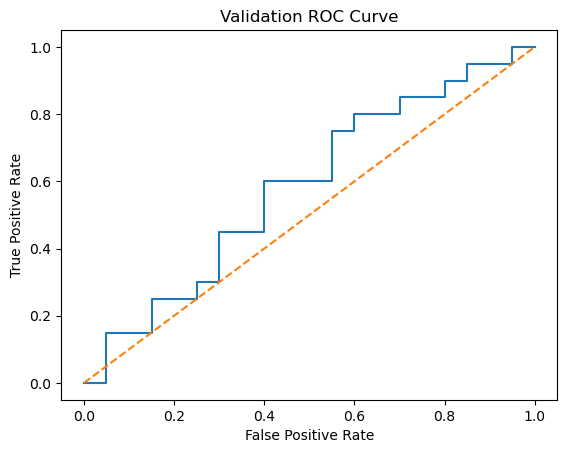

Confusion Matrix:
[[ 4 16]
 [ 2 18]]
026 | Train Loss: 0.6802 | Train Acc: 0.5938 | 0.5750 | 0.5750 | 0.5484 | 0.8500 | 0.6025 | 0.5951 | 0.1796
027 | Train Loss: 0.6692 | Train Acc: 0.5437 | 0.5000 | 0.5000 | 0.5000 | 0.9500 | 0.6500 | 0.6508 | 0.0000
028 | Train Loss: 0.6697 | Train Acc: 0.6312 | 0.5750 | 0.5750 | 0.5455 | 0.9000 | 0.6200 | 0.6078 | 0.1974
029 | Train Loss: 0.6579 | Train Acc: 0.6750 | 0.5750 | 0.5750 | 0.5556 | 0.7500 | 0.6025 | 0.5887 | 0.1601
030 | Train Loss: 0.6508 | Train Acc: 0.5938 | 0.5750 | 0.5750 | 0.5455 | 0.9000 | 0.6625 | 0.6622 | 0.1974
031 | Train Loss: 0.6488 | Train Acc: 0.6687 | 0.5500 | 0.5500 | 0.6000 | 0.3000 | 0.5925 | 0.5716 | 0.1155
032 | Train Loss: 0.6643 | Train Acc: 0.6625 | 0.6250 | 0.6250 | 0.5806 | 0.9000 | 0.6500 | 0.6233 | 0.2993
033 | Train Loss: 0.6261 | Train Acc: 0.6687 | 0.6000 | 0.6000 | 0.5714 | 0.8000 | 0.6525 | 0.6202 | 0.2182
034 | Train Loss: 0.6170 | Train Acc: 0.6375 | 0.6000 | 0.6000 | 0.5588 | 0.9500 | 0.6900 | 0.6812 

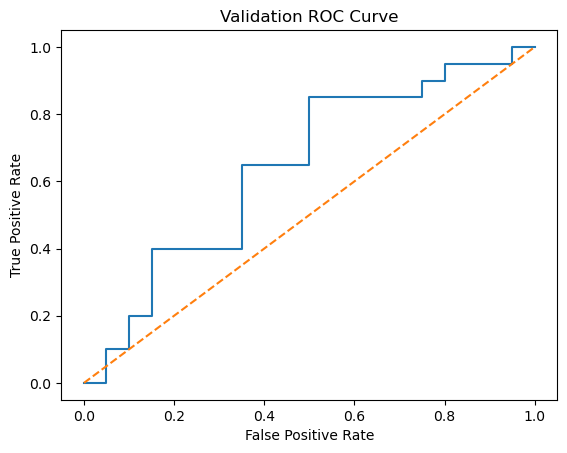

Confusion Matrix:
[[13  7]
 [ 7 13]]
051 | Train Loss: 0.5251 | Train Acc: 0.8187 | 0.6500 | 0.6500 | 0.6154 | 0.8000 | 0.6900 | 0.6822 | 0.3145
052 | Train Loss: 0.5209 | Train Acc: 0.8375 | 0.6500 | 0.6500 | 0.6250 | 0.7500 | 0.6875 | 0.6716 | 0.3062
053 | Train Loss: 0.5242 | Train Acc: 0.7812 | 0.5500 | 0.5500 | 0.6000 | 0.3000 | 0.6650 | 0.6197 | 0.1155
054 | Train Loss: 0.4726 | Train Acc: 0.7625 | 0.5750 | 0.5750 | 0.6667 | 0.3000 | 0.6550 | 0.6389 | 0.1796
055 | Train Loss: 0.5441 | Train Acc: 0.8313 | 0.6000 | 0.6000 | 0.5833 | 0.7000 | 0.7050 | 0.7097 | 0.2041
056 | Train Loss: 0.6591 | Train Acc: 0.6625 | 0.5250 | 0.5250 | 0.6000 | 0.1500 | 0.6200 | 0.5839 | 0.0756
057 | Train Loss: 0.5608 | Train Acc: 0.8313 | 0.6250 | 0.6250 | 0.6087 | 0.7000 | 0.6575 | 0.6350 | 0.2529
058 | Train Loss: 0.5380 | Train Acc: 0.8313 | 0.6250 | 0.6250 | 0.6316 | 0.6000 | 0.6475 | 0.6044 | 0.2503
059 | Train Loss: 0.5032 | Train Acc: 0.8063 | 0.5500 | 0.5500 | 0.5833 | 0.3500 | 0.6400 | 0.6073 

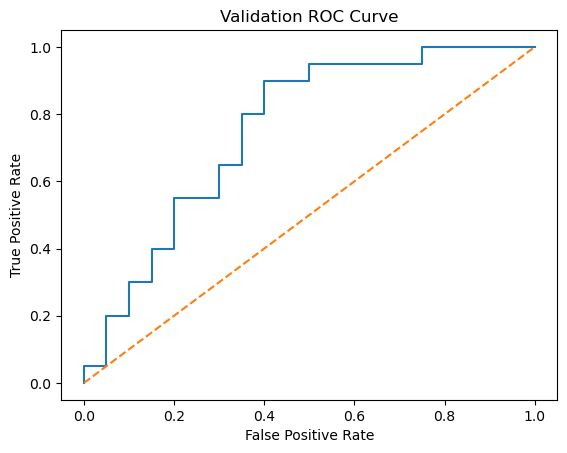

Confusion Matrix:
[[12  8]
 [ 3 17]]
076 | Train Loss: 0.2847 | Train Acc: 0.9187 | 0.7500 | 0.7500 | 0.6923 | 0.9000 | 0.7775 | 0.7376 | 0.5241
077 | Train Loss: 0.2668 | Train Acc: 0.7625 | 0.7000 | 0.7000 | 0.6333 | 0.9500 | 0.8000 | 0.7637 | 0.4619
078 | Train Loss: 0.2786 | Train Acc: 0.8938 | 0.7000 | 0.7000 | 0.6429 | 0.9000 | 0.7450 | 0.6663 | 0.4364
079 | Train Loss: 0.2818 | Train Acc: 0.9750 | 0.7250 | 0.7250 | 0.6957 | 0.8000 | 0.7525 | 0.7069 | 0.4551
080 | Train Loss: 0.2480 | Train Acc: 0.9750 | 0.7250 | 0.7250 | 0.6957 | 0.8000 | 0.7775 | 0.7318 | 0.4551
081 | Train Loss: 0.2302 | Train Acc: 0.9500 | 0.7250 | 0.7250 | 0.6667 | 0.9000 | 0.7825 | 0.7148 | 0.4804
082 | Train Loss: 0.2126 | Train Acc: 0.9625 | 0.6750 | 0.6750 | 0.6400 | 0.8000 | 0.7425 | 0.6681 | 0.3615
083 | Train Loss: 0.2025 | Train Acc: 0.9563 | 0.7000 | 0.7000 | 0.7222 | 0.6500 | 0.7400 | 0.6688 | 0.4020
084 | Train Loss: 0.1731 | Train Acc: 0.9875 | 0.7250 | 0.7250 | 0.6800 | 0.8500 | 0.7650 | 0.6929 

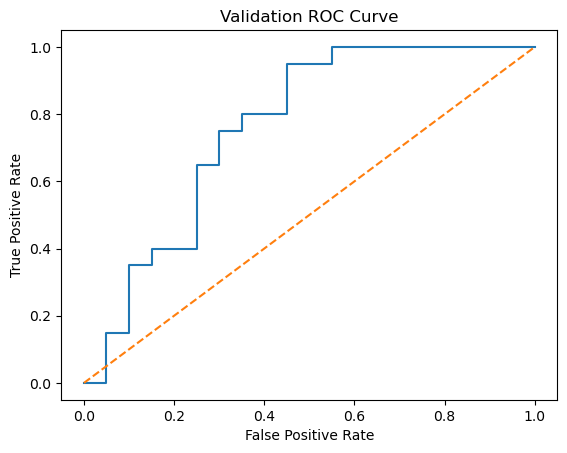

Confusion Matrix:
[[13  7]
 [ 4 16]]
101 | Train Loss: 0.0656 | Train Acc: 0.9938 | 0.7250 | 0.7250 | 0.6667 | 0.9000 | 0.7762 | 0.7006 | 0.4804
102 | Train Loss: 0.1037 | Train Acc: 1.0000 | 0.7000 | 0.7000 | 0.7000 | 0.7000 | 0.7625 | 0.6845 | 0.4000
103 | Train Loss: 0.0601 | Train Acc: 0.9875 | 0.6750 | 0.6750 | 0.7059 | 0.6000 | 0.7450 | 0.6732 | 0.3540
104 | Train Loss: 0.1333 | Train Acc: 0.9125 | 0.6500 | 0.6500 | 0.7500 | 0.4500 | 0.7475 | 0.7141 | 0.3273
105 | Train Loss: 0.1287 | Train Acc: 0.9812 | 0.7000 | 0.7000 | 0.7222 | 0.6500 | 0.7625 | 0.7076 | 0.4020
106 | Train Loss: 0.0749 | Train Acc: 0.9812 | 0.7500 | 0.7500 | 0.6786 | 0.9500 | 0.7775 | 0.7207 | 0.5455
107 | Train Loss: 0.1507 | Train Acc: 1.0000 | 0.7000 | 0.7000 | 0.6538 | 0.8500 | 0.7550 | 0.6868 | 0.4193
108 | Train Loss: 0.0974 | Train Acc: 0.9750 | 0.6500 | 0.6500 | 0.6875 | 0.5500 | 0.7275 | 0.6771 | 0.3062
109 | Train Loss: 0.0890 | Train Acc: 1.0000 | 0.7000 | 0.7000 | 0.6538 | 0.8500 | 0.7700 | 0.7016 

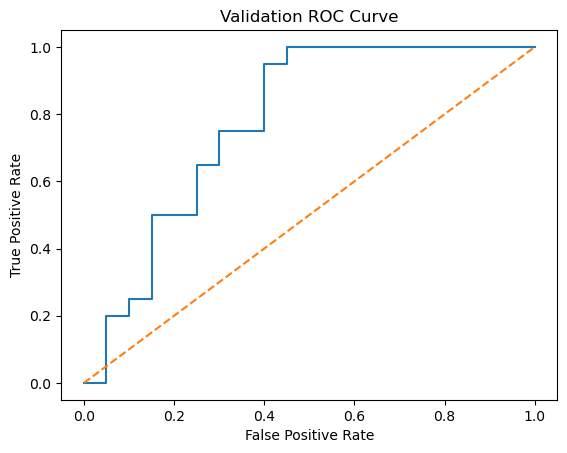

Confusion Matrix:
[[12  8]
 [ 1 19]]
126 | Train Loss: 0.0375 | Train Acc: 1.0000 | 0.7000 | 0.7000 | 0.7000 | 0.7000 | 0.7625 | 0.6854 | 0.4000
127 | Train Loss: 0.0191 | Train Acc: 1.0000 | 0.7250 | 0.7250 | 0.7143 | 0.7500 | 0.7775 | 0.7003 | 0.4506
128 | Train Loss: 0.0248 | Train Acc: 1.0000 | 0.7500 | 0.7500 | 0.6923 | 0.9000 | 0.7900 | 0.7126 | 0.5241
129 | Train Loss: 0.0305 | Train Acc: 1.0000 | 0.7000 | 0.7000 | 0.7222 | 0.6500 | 0.7900 | 0.7124 | 0.4020
130 | Train Loss: 0.0585 | Train Acc: 0.9875 | 0.7750 | 0.7750 | 0.6897 | 1.0000 | 0.8175 | 0.7617 | 0.6159
131 | Train Loss: 0.0900 | Train Acc: 0.8125 | 0.7000 | 0.7000 | 0.6250 | 1.0000 | 0.8375 | 0.7931 | 0.5000
132 | Train Loss: 0.2072 | Train Acc: 1.0000 | 0.6750 | 0.6750 | 0.6667 | 0.7000 | 0.7350 | 0.6720 | 0.3504
133 | Train Loss: 0.0684 | Train Acc: 0.9938 | 0.6750 | 0.6750 | 0.7059 | 0.6000 | 0.7475 | 0.6906 | 0.3540
134 | Train Loss: 0.0831 | Train Acc: 1.0000 | 0.6750 | 0.6750 | 0.6842 | 0.6500 | 0.7700 | 0.7077 

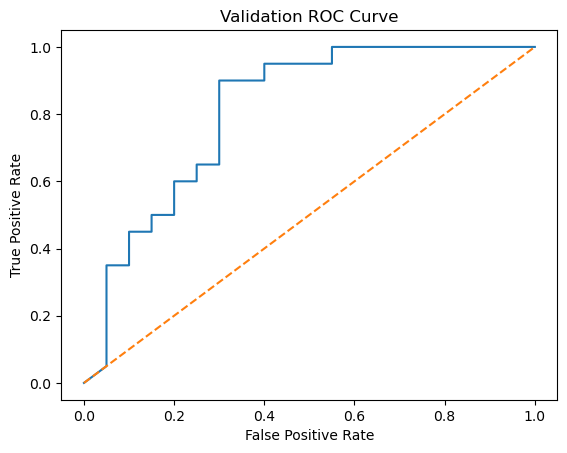

Confusion Matrix:
[[11  9]
 [ 1 19]]


In [22]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    confusion_matrix,
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    matthews_corrcoef
)
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, confusion_matrix
import lib.metrics

train_losses = []
val_losses = []
num_epochs = 150

print("Epoch | Acc | Bal_Acc | Prec | Rec | AUROC | AUPRC | MCC")

for epoch in range(num_epochs):
    train_loss = train(model, train_loader, optimizer, criterion, device)
    train_acc  = evaluate(model, train_loader, device)
    val_loss   = evaluate_loss(model, val_loader, criterion, device)
    val_acc    = evaluate(model, val_loader, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    val_auc, labels, probs = evaluate_auc(model, val_loader, device)
    preds = (probs >= 0.5).astype(int)

    bal_acc = balanced_accuracy_score(labels, preds)
    precision = precision_score(labels, preds)
    recall = recall_score(labels, preds)
    auprc = average_precision_score(labels, probs)
    mcc = matthews_corrcoef(labels, preds)
    
    cm = confusion_matrix(labels, preds)

    print(
        f"{epoch+1:03d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"{val_acc:.4f} | "
        f"{bal_acc:.4f} | "
        f"{precision:.4f} | "
        f"{recall:.4f} | "
        f"{val_auc:.4f} | "
        f"{auprc:.4f} | "
        f"{mcc:.4f}"
    )
    
    if (epoch+1) % 25 == 0:
        plot_roc(labels, probs)
        print("Confusion Matrix:")
        print(cm)